In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('HR_timeseries_BA.csv')
adj_matrix = pd.read_csv('BA_Nnodes100_Adj_deg_7_1.csv', header=None)

num_nodes = adj_matrix.shape[0]
data = data.values.reshape(len(data), num_nodes, -1)

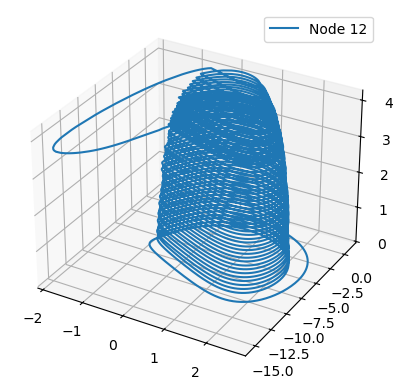

In [3]:
fig = plt.figure()
ax = plt.axes(projection='3d')
true_x = data[:,12,0] 
true_y = data[:,12,1]
true_z = data[:,12,2]
ax.plot(true_x, true_y, true_z, label='Node 12')  
ax.legend()
plt.show()


In [4]:
from math import exp

def dx_dt(t, x, y, z, neighbors, coupling_coeffs):
    self_dynamics = lambda x, y, z: (
        -0.707 * z
        - 0.909 * (x**3)
        + 2.519 * (x**2)
        + 0.890 * y
    )

    inter_dynamics = lambda x_i, x_j: (
        ((-0.182 * x_i) + 0.779)
        * (0.059 * (1 / (1 + exp(-x_j))) + 0.076)
    )

    dx = self_dynamics(x, y, z)

    for a_ij, neighbor in zip(coupling_coeffs, neighbors):
        if a_ij != 0:
            dx += a_ij * inter_dynamics(x, neighbor[t, 0])

    return dx

Using device: cuda


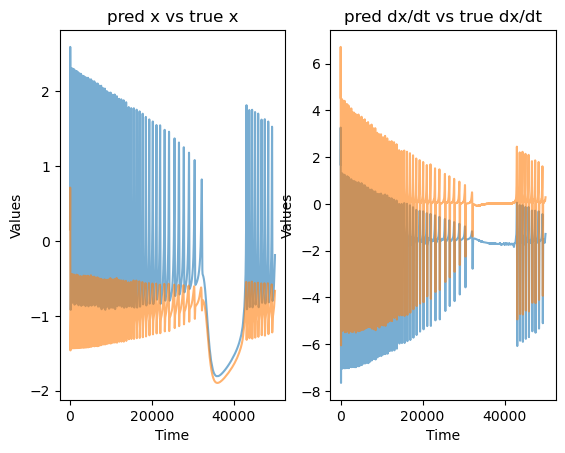

In [5]:
from FEX.utils.numerical_deriv import NumericalDeriv

node_idx = 12

dt = 0.01

resolution_factor = 1
true_dx_dt = NumericalDeriv(data, dt=0.01)

data_init = data[0, node_idx, :]

# Correct: shape is (num_nodes, timesteps, 3)
neighbors = np.transpose(data, (1, 0, 2))

# Correct: row for node 12, not column 12
coupling_coeffs = adj_matrix.iloc[node_idx].to_numpy(dtype=float)

x_values = data[:, node_idx, 0]
y_values = data[:, node_idx, 1]
z_values = data[:, node_idx, 2]

pred_x_values = [data_init[0]]

dx_dt_values = []

for t in range(len(data) - 1):
    dx_dt_curr = dx_dt(
        t,
        x_values[t],
        y_values[t],
        z_values[t],
        neighbors,
        coupling_coeffs
    )
    dx_dt_values.append(float(dx_dt_curr))
    
for t in range(len(data) - 1):
    dx_dt_curr = dx_dt(
        t,
        pred_x_values[-1],
        y_values[t],
        z_values[t],
        neighbors,
        coupling_coeffs
    )
    x_next = pred_x_values[-1] + dt * dx_dt_curr
    pred_x_values.append(float(x_next))


fig, ax = plt.subplots(1, 2)
ax[0].plot(x_values, alpha=0.6)
ax[0].plot(pred_x_values, alpha=0.6)
ax[0].set_title('pred x vs true x')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Values')

ax[1].plot(dx_dt_values, alpha=0.6)
ax[1].plot(true_dx_dt[:, node_idx, 0], alpha=0.6)
ax[1].set_title('pred dx/dt vs true dx/dt')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Values')

plt.show()

In [6]:
from math import exp

def safe_exp(v, clip=30.0):
    v = max(min(float(v), clip), -clip)
    return exp(v)

def sigmoid(v):
    return 1 / (1 + safe_exp(-v))

def safe_square(v, clip=100.0):
    v = max(min(float(v), clip), -clip)
    return v * v


def dx_dt(t, x, y, z, neighbors, coupling_coeffs):
    x_safe = max(min(float(x), 100.0), -100.0)

    self_dynamics = (
        0.442 * safe_square(x_safe)
        - 0.217 * x_safe
        + 7.130 * sigmoid(y)
        - 1.640 * safe_exp(y)
        - 1.388
    )

    dx = self_dynamics

    for a_ij, neighbor in zip(coupling_coeffs, neighbors):
        if a_ij != 0:
            z_j = neighbor[t, 2]

            inter = (
                (11.119 * safe_exp(y) + 1.090)
                / (8.829 * safe_exp(z_j) + 5.526)
            )

            dx += a_ij * inter

    return dx

In [7]:


# Correct: shape is (num_nodes, timesteps, 3)
neighbors = np.transpose(data, (1, 0, 2))

# Correct: row for node 12, not column 12
coupling_coeffs = adj_matrix.iloc[node_idx].to_numpy(dtype=float)

x_values = data[:, node_idx, 0]
y_values = data[:, node_idx, 1]
z_values = data[:, node_idx, 2]

dx_dt_values = []
pred_x_values = [data_init[0]]

for t in range(len(data) - 1):
    dx_dt_curr = dx_dt(
        t,
        x_values[t],
        y_values[t],
        z_values[t],
        neighbors,
        coupling_coeffs
    )
    dx_dt_values.append(float(dx_dt_curr))
    
for t in range(len(data) - 1):
    dx_dt_curr = dx_dt(
        t,
        pred_x_values[-1],
        y_values[t],
        z_values[t],
        neighbors,
        coupling_coeffs
    )
    x_next = pred_x_values[-1] + dt * dx_dt_curr
    pred_x_values.append(float(x_next))

pred_x_values = np.array(pred_x_values)

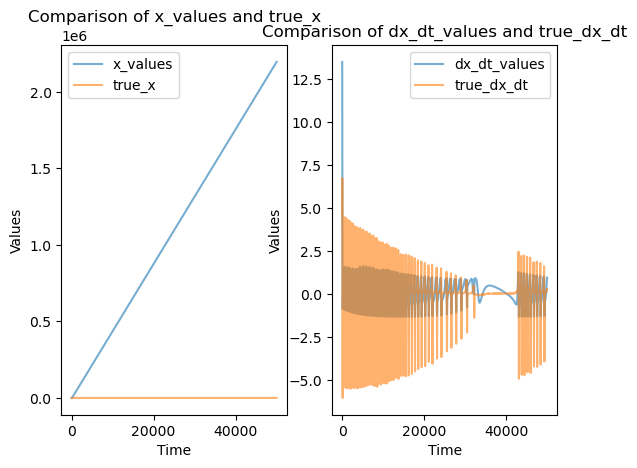

In [8]:
fig, ax = plt.subplots(1,2)
ax[0].plot(pred_x_values, alpha=0.6)
ax[0].plot(true_x, alpha=0.6)
ax[0].legend(['x_values', 'true_x'])
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Values')
ax[0].set_title('Comparison of x_values and true_x')

ax[1].plot(dx_dt_values, alpha=0.6)
ax[1].plot(true_dx_dt[:, node_idx, 0], alpha=0.6)
ax[1].legend(['dx_dt_values', 'true_dx_dt'])
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Values')
ax[1].set_title('Comparison of dx_dt_values and true_dx_dt')
plt.show()